# Practical Work 6: Analyse & Compare Clustering Models

**Datasets:** Iris, Spotify

**Algorithms:** K-Means, PAM, CLARANS, CLARA, Hierarchical (Agglomerative & Divisive), DBSCAN, SOM

**Metrics:** Inertia, Silhouette Score, Calinski-Harabasz Index, Davies-Bouldin Index

## 1. Imports and Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score, pairwise_distances
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from minisom import MiniSom
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
print('All imports successful!')

All imports successful!


## 2. Load and Explore Datasets

In [2]:
# Load Iris dataset
iris_df = pd.read_csv('iris.csv')
print('=== IRIS DATASET ===')
print(f'Shape: {iris_df.shape}')
display(iris_df.head())
display(iris_df.describe())
print(f'\nSpecies distribution:\n{iris_df["species"].value_counts()}')

=== IRIS DATASET ===
Shape: (150, 5)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000



Species distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


In [3]:
# Load Spotify dataset
spotify_df = pd.read_csv('spotify.csv')
print('=== SPOTIFY DATASET ===')
print(f'Shape: {spotify_df.shape}')
display(spotify_df.head())
display(spotify_df.describe())
print(f'\nMissing values:\n{spotify_df.isnull().sum()}')

=== SPOTIFY DATASET ===
Shape: (500, 11)


,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,popularity
0,0.704132,0.365250,-21.501468,0.109867,0.127507,0.072450,0.430547,0.256138,60.000000,174301,86
1,0.644772,0.365801,-17.990615,0.097652,0.357822,0.304997,0.297621,0.601362,114.460660,266676,6
2,0.685086,0.699544,-5.644016,0.092248,0.193538,0.126010,0.542445,0.377514,154.774870,211340,90
3,0.504728,0.632413,-29.584136,0.067292,0.319970,0.086841,0.192286,0.937547,123.536984,212954,76
4,0.896150,0.384008,-10.518635,0.075217,0.264123,0.010441,0.402932,0.404740,153.300795,281973,50


,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,popularity
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,0.626497,0.590086,-14.799193,0.097803,0.300317,0.138453,0.251338,0.503864,118.532340,220693.960000,51.458000
std,0.151938,0.169759,8.732225,0.099192,0.164642,0.134935,0.117917,0.183145,25.125767,59794.256694,29.470481
min,0.206914,0.072561,-29.993189,0.000620,0.013338,0.000036,0.053680,0.077517,60.000000,60000.000000,0.000000
25%,0.526234,0.483715,-22.509672,0.030384,0.168368,0.039799,0.164223,0.367757,100.866747,180644.500000,25.750000
50%,0.634631,0.593797,-15.104772,0.064635,0.282609,0.093721,0.232915,0.501971,118.599401,218812.000000,52.000000
75%,0.738303,0.717995,-7.086011,0.130404,0.414063,0.196338,0.321318,0.641737,134.899817,260177.000000,77.000000
max,0.984467,0.971897,-0.091517,0.671956,0.741945,0.820985,0.727586,0.937632,192.925819,391217.000000,100.000000



Missing values:
danceability        0
energy              0
loudness            0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
duration_ms         0
popularity          0
dtype: int64


## 3. Data Preprocessing

In [4]:
# Prepare Iris features (drop species column)
iris_features = iris_df.drop('species', axis=1)
scaler_iris = StandardScaler()
iris_scaled = scaler_iris.fit_transform(iris_features)

# Prepare Spotify features (all columns are numeric)
scaler_spotify = StandardScaler()
spotify_scaled = scaler_spotify.fit_transform(spotify_df)

# PCA for visualization (2D)
pca_iris = PCA(n_components=2)
iris_pca = pca_iris.fit_transform(iris_scaled)
print(f'Iris PCA explained variance: {pca_iris.explained_variance_ratio_.sum():.3f}')

pca_spotify = PCA(n_components=2)
spotify_pca = pca_spotify.fit_transform(spotify_scaled)
print(f'Spotify PCA explained variance: {pca_spotify.explained_variance_ratio_.sum():.3f}')

Iris PCA explained variance: 0.958
Spotify PCA explained variance: 0.222


## 4. Helper Functions

In [5]:
def evaluate_clustering(X, labels, name=''):
    """Compute clustering metrics. Returns dict of scores."""
    n_clusters = len(set(labels) - {-1})
    n_noise = list(labels).count(-1)
    valid = labels != -1
    
    result = {'Algorithm': name, 'n_clusters': n_clusters, 'n_noise': n_noise}
    
    if n_clusters >= 2 and valid.sum() > n_clusters:
        result['Silhouette'] = silhouette_score(X[valid], labels[valid])
        result['Calinski-Harabasz'] = calinski_harabasz_score(X[valid], labels[valid])
        result['Davies-Bouldin'] = davies_bouldin_score(X[valid], labels[valid])
    else:
        result['Silhouette'] = np.nan
        result['Calinski-Harabasz'] = np.nan
        result['Davies-Bouldin'] = np.nan
    
    return result


def plot_clusters(pca_data, labels, title, ax):
    """Plot 2D PCA scatter of clusters."""
    unique_labels = sorted(set(labels))
    palette = sns.color_palette('tab10', len(unique_labels))
    for i, label in enumerate(unique_labels):
        mask = labels == label
        name = 'Noise' if label == -1 else f'Cluster {label}'
        color = 'gray' if label == -1 else palette[i]
        marker = 'x' if label == -1 else 'o'
        ax.scatter(pca_data[mask, 0], pca_data[mask, 1], c=[color], label=name,
                   marker=marker, s=30, alpha=0.7)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.legend(fontsize=8, loc='best')


def kmedoids_pam(X, n_clusters, max_iter=100, seed=42):
    """PAM (Partitioning Around Medoids) implementation."""
    rng = np.random.RandomState(seed)
    n = len(X)
    dist_matrix = pairwise_distances(X)
    
    # Initialize medoids randomly
    medoids = rng.choice(n, n_clusters, replace=False)
    
    for _ in range(max_iter):
        # Assign points to nearest medoid
        labels = dist_matrix[:, medoids].argmin(axis=1)
        
        # Update medoids
        new_medoids = medoids.copy()
        for j in range(n_clusters):
            cluster_mask = labels == j
            cluster_indices = np.where(cluster_mask)[0]
            if len(cluster_indices) == 0:
                continue
            # Find point that minimizes total distance within cluster
            sub_dist = dist_matrix[np.ix_(cluster_indices, cluster_indices)]
            best = cluster_indices[sub_dist.sum(axis=1).argmin()]
            new_medoids[j] = best
        
        if np.array_equal(new_medoids, medoids):
            break
        medoids = new_medoids
    
    labels = dist_matrix[:, medoids].argmin(axis=1)
    inertia = sum(dist_matrix[i, medoids[labels[i]]] ** 2 for i in range(n))
    return labels, medoids, inertia


def clara(X, n_clusters, n_samples=5, sample_size=None, seed=42):
    """CLARA: runs PAM on subsamples, picks the best."""
    rng = np.random.RandomState(seed)
    n = len(X)
    if sample_size is None:
        sample_size = min(40 + 2 * n_clusters, n)
    
    best_score = -np.inf
    best_labels = None
    best_inertia = None
    
    for i in range(n_samples):
        idx = rng.choice(n, size=sample_size, replace=False)
        sub_labels, sub_medoids, _ = kmedoids_pam(X[idx], n_clusters, seed=seed + i)
        
        # Map medoids back to full dataset indices
        full_medoids = idx[sub_medoids]
        
        # Assign all points to nearest medoid
        dist_matrix_full = pairwise_distances(X, X[full_medoids])
        trial_labels = dist_matrix_full.argmin(axis=1)
        trial_inertia = dist_matrix_full.min(axis=1).sum()
        
        score = silhouette_score(X, trial_labels)
        if score > best_score:
            best_score = score
            best_labels = trial_labels
            best_inertia = trial_inertia
    
    return best_labels, best_inertia


def clarans(X, n_clusters, num_local=5, max_neighbors=10, seed=42):
    """CLARANS: randomized medoid search."""
    rng = np.random.RandomState(seed)
    n = len(X)
    best_cost = np.inf
    best_medoids = None
    for _ in range(num_local):
        medoids = rng.choice(n, n_clusters, replace=False)
        for _ in range(max_neighbors):
            dists = pairwise_distances(X, X[medoids])
            current_cost = dists.min(axis=1).sum()
            m_idx = rng.randint(n_clusters)
            candidate = rng.randint(n)
            new_medoids = medoids.copy()
            new_medoids[m_idx] = candidate
            new_dists = pairwise_distances(X, X[new_medoids])
            new_cost = new_dists.min(axis=1).sum()
            if new_cost < current_cost:
                medoids = new_medoids
        dists = pairwise_distances(X, X[medoids])
        cost = dists.min(axis=1).sum()
        if cost < best_cost:
            best_cost = cost
            best_medoids = medoids.copy()
    dists = pairwise_distances(X, X[best_medoids])
    return dists.argmin(axis=1), best_cost


def divisive_clustering(X, n_clusters):
    """Top-down bisecting K-Means."""
    labels = np.zeros(len(X), dtype=int)
    current_k = 1
    while current_k < n_clusters:
        unique, counts = np.unique(labels, return_counts=True)
        largest = unique[counts.argmax()]
        mask = labels == largest
        km2 = KMeans(n_clusters=2, n_init=10, random_state=42)
        sub_labels = km2.fit_predict(X[mask])
        labels[mask] = np.where(sub_labels == 0, largest, current_k)
        current_k += 1
    return labels

print('Helper functions defined.')

Helper functions defined.


---
# Part A: Iris Dataset Clustering
---

## 5. Optimal K Selection (Elbow & Silhouette)

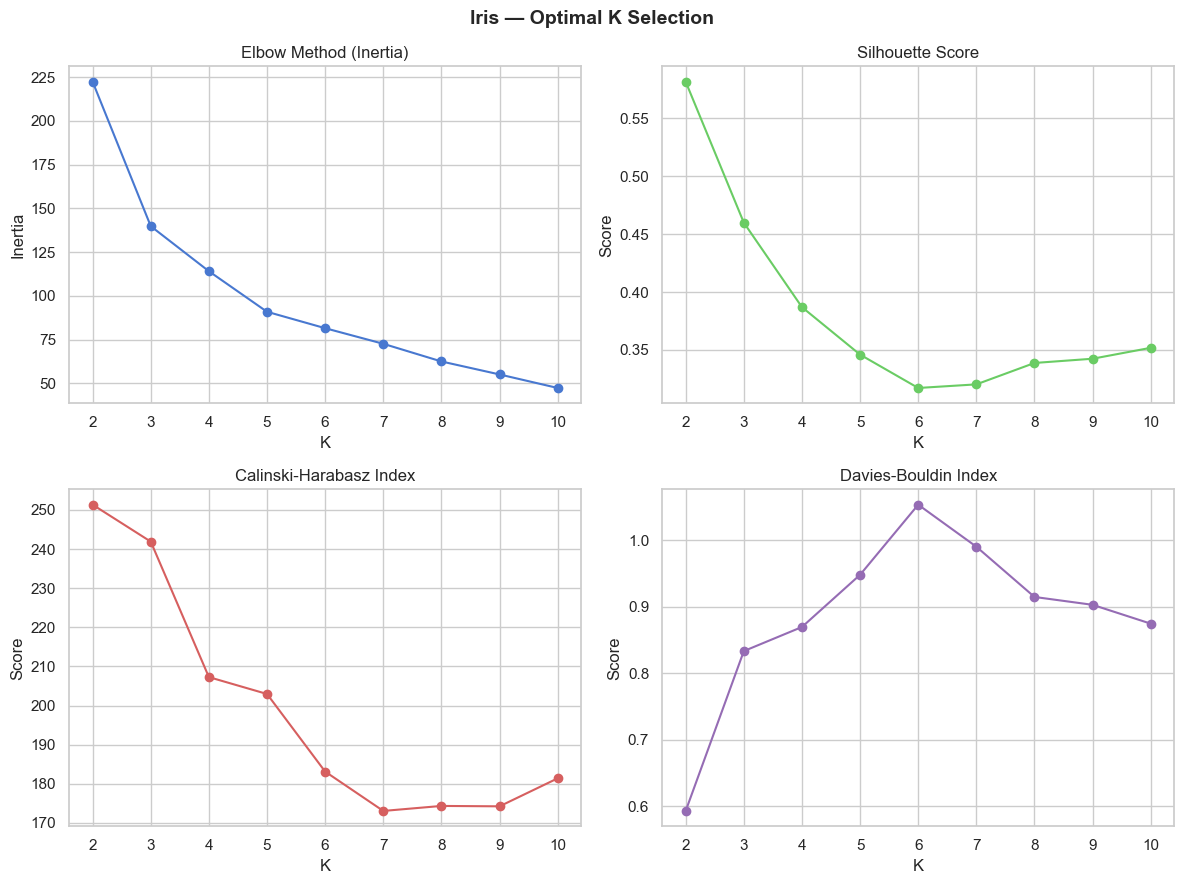


Optimal K for Iris: 3 (matches known 3 species)


In [6]:
K_range = range(2, 11)
inertias, silhouettes, chs, dbs = [], [], [], []

for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(iris_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(iris_scaled, labels))
    chs.append(calinski_harabasz_score(iris_scaled, labels))
    dbs.append(davies_bouldin_score(iris_scaled, labels))

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle('Iris — Optimal K Selection', fontsize=14, fontweight='bold')

axes[0, 0].plot(K_range, inertias, 'bo-')
axes[0, 0].set_title('Elbow Method (Inertia)')
axes[0, 0].set_xlabel('K'); axes[0, 0].set_ylabel('Inertia')

axes[0, 1].plot(K_range, silhouettes, 'go-')
axes[0, 1].set_title('Silhouette Score')
axes[0, 1].set_xlabel('K'); axes[0, 1].set_ylabel('Score')

axes[1, 0].plot(K_range, chs, 'ro-')
axes[1, 0].set_title('Calinski-Harabasz Index')
axes[1, 0].set_xlabel('K'); axes[1, 0].set_ylabel('Score')

axes[1, 1].plot(K_range, dbs, 'mo-')
axes[1, 1].set_title('Davies-Bouldin Index')
axes[1, 1].set_xlabel('K'); axes[1, 1].set_ylabel('Score')

plt.tight_layout()
plt.savefig('iris_optimal_k.png', dpi=150, bbox_inches='tight')
plt.show()

best_k_iris = 3
print(f'\nOptimal K for Iris: {best_k_iris} (matches known 3 species)')

## 6. Clustering Algorithms on Iris

In [7]:
iris_results = []
iris_all_labels = {}
K = best_k_iris

# 1. K-Means
km = KMeans(n_clusters=K, n_init=10, random_state=42)
labels_km = km.fit_predict(iris_scaled)
res = evaluate_clustering(iris_scaled, labels_km, 'K-Means')
res['Inertia'] = km.inertia_
iris_results.append(res)
iris_all_labels['K-Means'] = labels_km

# 2. PAM (K-Medoids)
labels_pam, medoids_pam, pam_inertia = kmedoids_pam(iris_scaled, K, seed=42)
res = evaluate_clustering(iris_scaled, labels_pam, 'PAM')
res['Inertia'] = pam_inertia
iris_results.append(res)
iris_all_labels['PAM'] = labels_pam

# 3. CLARA
labels_clara, clara_inertia = clara(iris_scaled, K, n_samples=5, sample_size=80, seed=42)
res = evaluate_clustering(iris_scaled, labels_clara, 'CLARA')
res['Inertia'] = clara_inertia
iris_results.append(res)
iris_all_labels['CLARA'] = labels_clara

# 4. CLARANS
labels_clarans, clarans_cost = clarans(iris_scaled, K, num_local=5, max_neighbors=15, seed=42)
res = evaluate_clustering(iris_scaled, labels_clarans, 'CLARANS')
res['Inertia'] = clarans_cost
iris_results.append(res)
iris_all_labels['CLARANS'] = labels_clarans

# 5. Agglomerative Clustering
agg = AgglomerativeClustering(n_clusters=K, linkage='ward')
labels_agg = agg.fit_predict(iris_scaled)
res = evaluate_clustering(iris_scaled, labels_agg, 'Agglomerative')
res['Inertia'] = np.nan
iris_results.append(res)
iris_all_labels['Agglomerative'] = labels_agg

# 6. Divisive Clustering
labels_div = divisive_clustering(iris_scaled, K)
res = evaluate_clustering(iris_scaled, labels_div, 'Divisive')
res['Inertia'] = np.nan
iris_results.append(res)
iris_all_labels['Divisive'] = labels_div

# 7. DBSCAN
dbscan = DBSCAN(eps=0.9, min_samples=5)
labels_db = dbscan.fit_predict(iris_scaled)
res = evaluate_clustering(iris_scaled, labels_db, 'DBSCAN')
res['Inertia'] = np.nan
iris_results.append(res)
iris_all_labels['DBSCAN'] = labels_db

# 8. SOM (Self-Organizing Map)
som_size = 3
som = MiniSom(som_size, som_size, iris_scaled.shape[1], sigma=1.0, learning_rate=0.5, random_seed=42)
som.train(iris_scaled, 500)
som_labels = np.array([som.winner(x)[0] * som_size + som.winner(x)[1] for x in iris_scaled])
weights = som.get_weights().reshape(-1, iris_scaled.shape[1])
km_som = KMeans(n_clusters=K, n_init=10, random_state=42)
neuron_clusters = km_som.fit_predict(weights)
labels_som = np.array([neuron_clusters[l] for l in som_labels])
res = evaluate_clustering(iris_scaled, labels_som, 'SOM')
res['Inertia'] = np.nan
iris_results.append(res)
iris_all_labels['SOM'] = labels_som

print('All Iris clustering complete!')

All Iris clustering complete!


## 7. Iris — Results Comparison Table

In [8]:
iris_results_df = pd.DataFrame(iris_results)
iris_results_df = iris_results_df[['Algorithm', 'n_clusters', 'n_noise', 'Inertia', 'Silhouette', 'Calinski-Harabasz', 'Davies-Bouldin']]
display(iris_results_df.round(4).style.highlight_max(subset=['Silhouette', 'Calinski-Harabasz'], color='lightgreen')
        .highlight_min(subset=['Davies-Bouldin'], color='lightgreen'))

,Algorithm,n_clusters,n_noise,Inertia,Silhouette,Calinski-Harabasz,Davies-Bouldin
0,K-Means,3,0,139.820500,0.459900,241.904400,0.833600
1,PAM,3,0,155.124200,0.460500,235.152100,0.832400
2,CLARA,3,0,155.593100,0.495100,149.823400,0.653300
3,CLARANS,3,0,138.889800,0.447900,226.074900,0.862100
4,Agglomerative,3,0,nan,0.446700,222.719200,0.803500
5,Divisive,3,0,nan,0.459900,241.904400,0.833600
6,DBSCAN,2,4,nan,0.597900,277.651000,0.568800
7,SOM,3,0,nan,0.450000,210.799900,0.772600


## 8. Iris — Cluster Visualizations (PCA 2D)

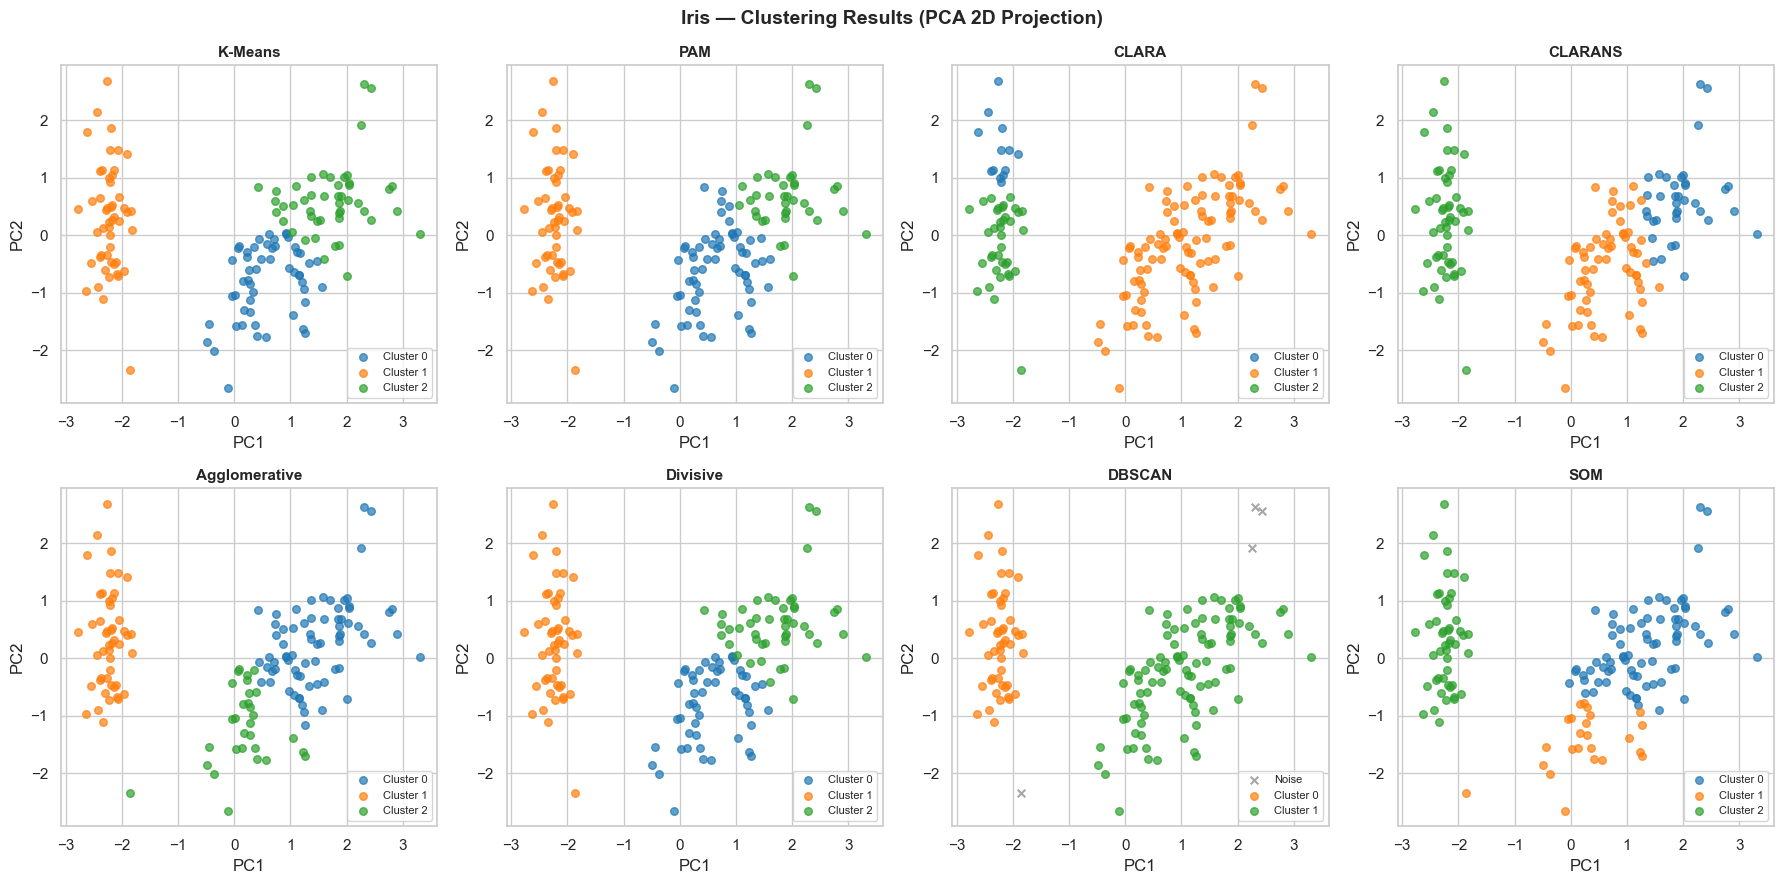

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle('Iris — Clustering Results (PCA 2D Projection)', fontsize=14, fontweight='bold')

for ax, (name, labels) in zip(axes.ravel(), iris_all_labels.items()):
    plot_clusters(iris_pca, labels, name, ax)

plt.tight_layout()
plt.savefig('iris_clustering_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Iris — Dendrogram (Hierarchical)

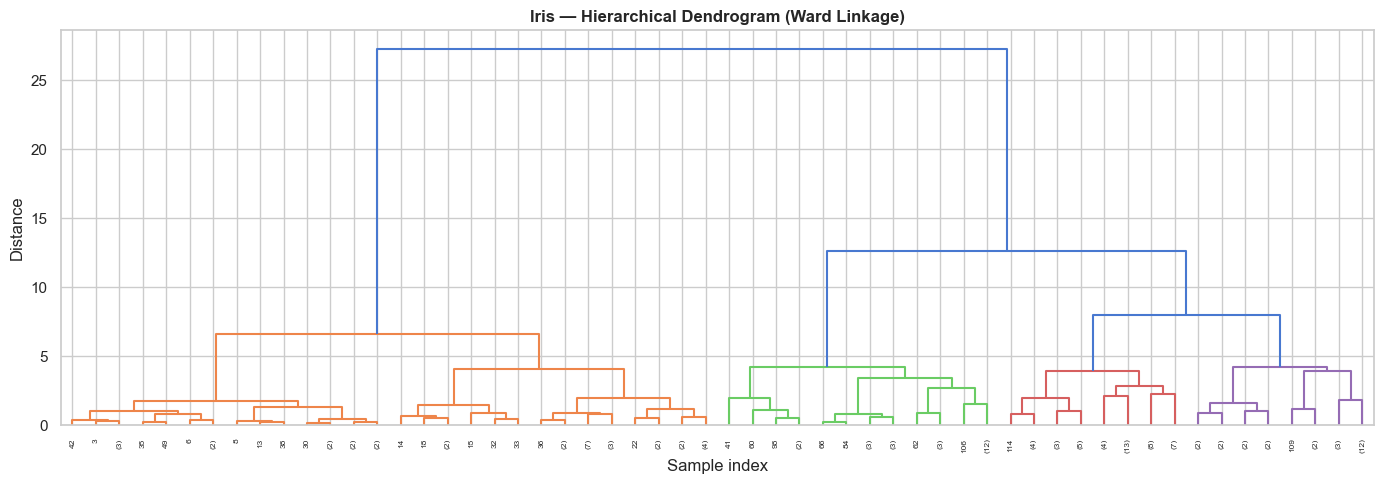

In [10]:
Z = linkage(iris_scaled, method='ward')
fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(Z, truncate_mode='level', p=5, ax=ax, color_threshold=7)
ax.set_title('Iris — Hierarchical Dendrogram (Ward Linkage)', fontweight='bold')
ax.set_xlabel('Sample index')
ax.set_ylabel('Distance')
plt.tight_layout()
plt.savefig('iris_dendrogram.png', dpi=150, bbox_inches='tight')
plt.show()

---
# Part B: Spotify Dataset Clustering
---

## 10. Optimal K Selection — Spotify

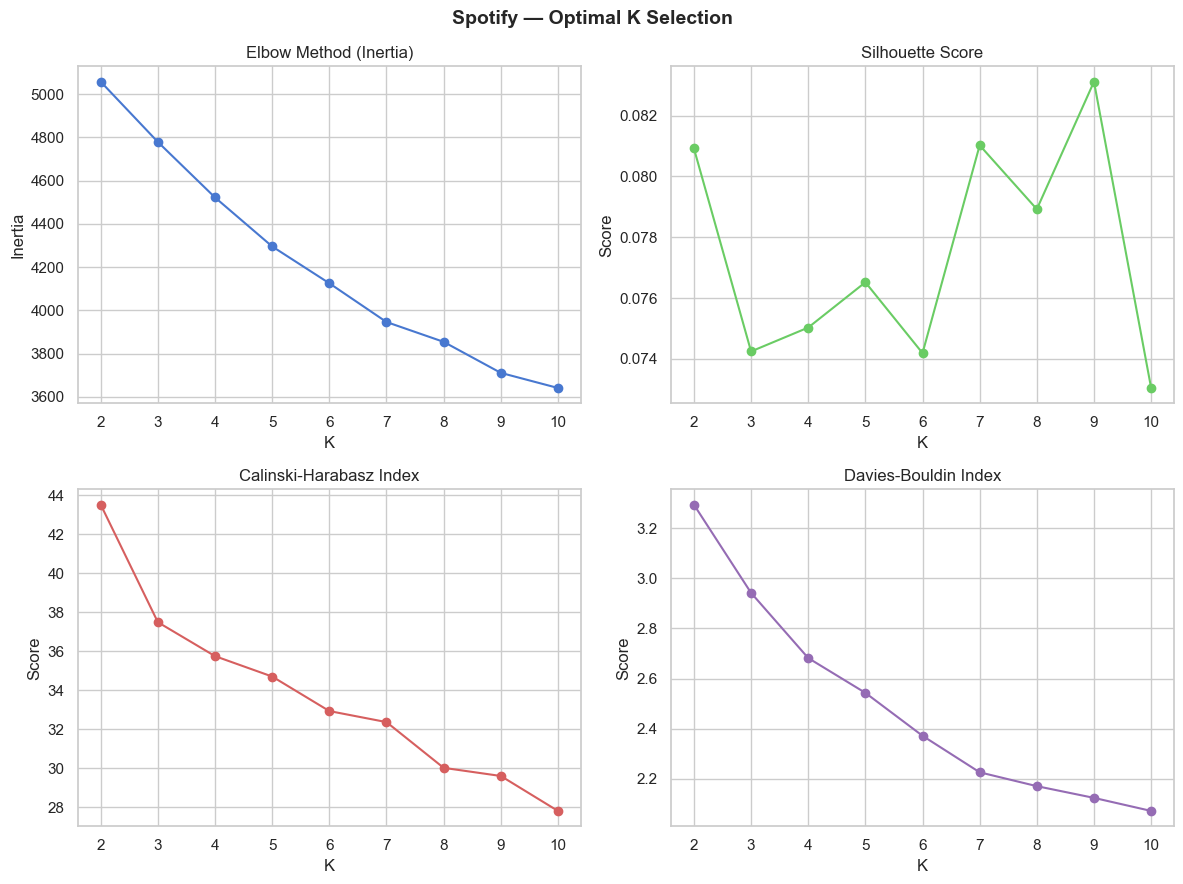


Optimal K for Spotify (by Silhouette): 9


In [11]:
K_range_sp = range(2, 11)
inertias_sp, sils_sp, chs_sp, dbs_sp = [], [], [], []

for k in K_range_sp:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(spotify_scaled)
    inertias_sp.append(km.inertia_)
    sils_sp.append(silhouette_score(spotify_scaled, labels))
    chs_sp.append(calinski_harabasz_score(spotify_scaled, labels))
    dbs_sp.append(davies_bouldin_score(spotify_scaled, labels))

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle('Spotify — Optimal K Selection', fontsize=14, fontweight='bold')

axes[0, 0].plot(K_range_sp, inertias_sp, 'bo-')
axes[0, 0].set_title('Elbow Method (Inertia)')
axes[0, 0].set_xlabel('K'); axes[0, 0].set_ylabel('Inertia')

axes[0, 1].plot(K_range_sp, sils_sp, 'go-')
axes[0, 1].set_title('Silhouette Score')
axes[0, 1].set_xlabel('K'); axes[0, 1].set_ylabel('Score')

axes[1, 0].plot(K_range_sp, chs_sp, 'ro-')
axes[1, 0].set_title('Calinski-Harabasz Index')
axes[1, 0].set_xlabel('K'); axes[1, 0].set_ylabel('Score')

axes[1, 1].plot(K_range_sp, dbs_sp, 'mo-')
axes[1, 1].set_title('Davies-Bouldin Index')
axes[1, 1].set_xlabel('K'); axes[1, 1].set_ylabel('Score')

plt.tight_layout()
plt.savefig('spotify_optimal_k.png', dpi=150, bbox_inches='tight')
plt.show()

best_k_sp = K_range_sp[np.argmax(sils_sp)]
print(f'\nOptimal K for Spotify (by Silhouette): {best_k_sp}')

## 11. Clustering Algorithms on Spotify

In [12]:
sp_results = []
sp_all_labels = {}
K_sp = best_k_sp

# 1. K-Means
km = KMeans(n_clusters=K_sp, n_init=10, random_state=42)
labels_km = km.fit_predict(spotify_scaled)
res = evaluate_clustering(spotify_scaled, labels_km, 'K-Means')
res['Inertia'] = km.inertia_
sp_results.append(res)
sp_all_labels['K-Means'] = labels_km

# 2. PAM
labels_pam, _, pam_inertia = kmedoids_pam(spotify_scaled, K_sp, seed=42)
res = evaluate_clustering(spotify_scaled, labels_pam, 'PAM')
res['Inertia'] = pam_inertia
sp_results.append(res)
sp_all_labels['PAM'] = labels_pam

# 3. CLARA
labels_clara, clara_inertia = clara(spotify_scaled, K_sp, n_samples=5, sample_size=200, seed=42)
res = evaluate_clustering(spotify_scaled, labels_clara, 'CLARA')
res['Inertia'] = clara_inertia
sp_results.append(res)
sp_all_labels['CLARA'] = labels_clara

# 4. CLARANS
labels_clarans, clarans_cost = clarans(spotify_scaled, K_sp, num_local=3, max_neighbors=15, seed=42)
res = evaluate_clustering(spotify_scaled, labels_clarans, 'CLARANS')
res['Inertia'] = clarans_cost
sp_results.append(res)
sp_all_labels['CLARANS'] = labels_clarans

# 5. Agglomerative
agg = AgglomerativeClustering(n_clusters=K_sp, linkage='ward')
labels_agg = agg.fit_predict(spotify_scaled)
res = evaluate_clustering(spotify_scaled, labels_agg, 'Agglomerative')
res['Inertia'] = np.nan
sp_results.append(res)
sp_all_labels['Agglomerative'] = labels_agg

# 6. Divisive
labels_div = divisive_clustering(spotify_scaled, K_sp)
res = evaluate_clustering(spotify_scaled, labels_div, 'Divisive')
res['Inertia'] = np.nan
sp_results.append(res)
sp_all_labels['Divisive'] = labels_div

# 7. DBSCAN
dbscan = DBSCAN(eps=2.5, min_samples=5)
labels_db = dbscan.fit_predict(spotify_scaled)
res = evaluate_clustering(spotify_scaled, labels_db, 'DBSCAN')
res['Inertia'] = np.nan
sp_results.append(res)
sp_all_labels['DBSCAN'] = labels_db

# 8. SOM
som_size = 3
som = MiniSom(som_size, som_size, spotify_scaled.shape[1], sigma=1.0, learning_rate=0.5, random_seed=42)
som.train(spotify_scaled, 1000)
som_labels = np.array([som.winner(x)[0] * som_size + som.winner(x)[1] for x in spotify_scaled])
weights = som.get_weights().reshape(-1, spotify_scaled.shape[1])
km_som = KMeans(n_clusters=K_sp, n_init=10, random_state=42)
neuron_clusters = km_som.fit_predict(weights)
labels_som = np.array([neuron_clusters[l] for l in som_labels])
res = evaluate_clustering(spotify_scaled, labels_som, 'SOM')
res['Inertia'] = np.nan
sp_results.append(res)
sp_all_labels['SOM'] = labels_som

print('All Spotify clustering complete!')

All Spotify clustering complete!


## 12. Spotify — Results Comparison Table

In [13]:
sp_results_df = pd.DataFrame(sp_results)
sp_results_df = sp_results_df[['Algorithm', 'n_clusters', 'n_noise', 'Inertia', 'Silhouette', 'Calinski-Harabasz', 'Davies-Bouldin']]
display(sp_results_df.round(4).style.highlight_max(subset=['Silhouette', 'Calinski-Harabasz'], color='lightgreen')
        .highlight_min(subset=['Davies-Bouldin'], color='lightgreen'))

,Algorithm,n_clusters,n_noise,Inertia,Silhouette,Calinski-Harabasz,Davies-Bouldin
0,K-Means,9,0,3710.480600,0.083100,29.600400,2.124100
1,PAM,9,0,4750.146200,0.032800,19.036500,2.640400
2,CLARA,9,0,1509.477700,0.052500,19.541300,2.436100
3,CLARANS,9,0,1517.805900,0.026600,17.688400,2.665100
4,Agglomerative,9,0,nan,0.041700,22.960600,2.479800
5,Divisive,9,0,nan,0.048300,22.813000,2.628300
6,DBSCAN,1,116,nan,nan,nan,nan
7,SOM,9,0,nan,0.062400,25.778100,2.396100


## 13. Spotify — Cluster Visualizations (PCA 2D)

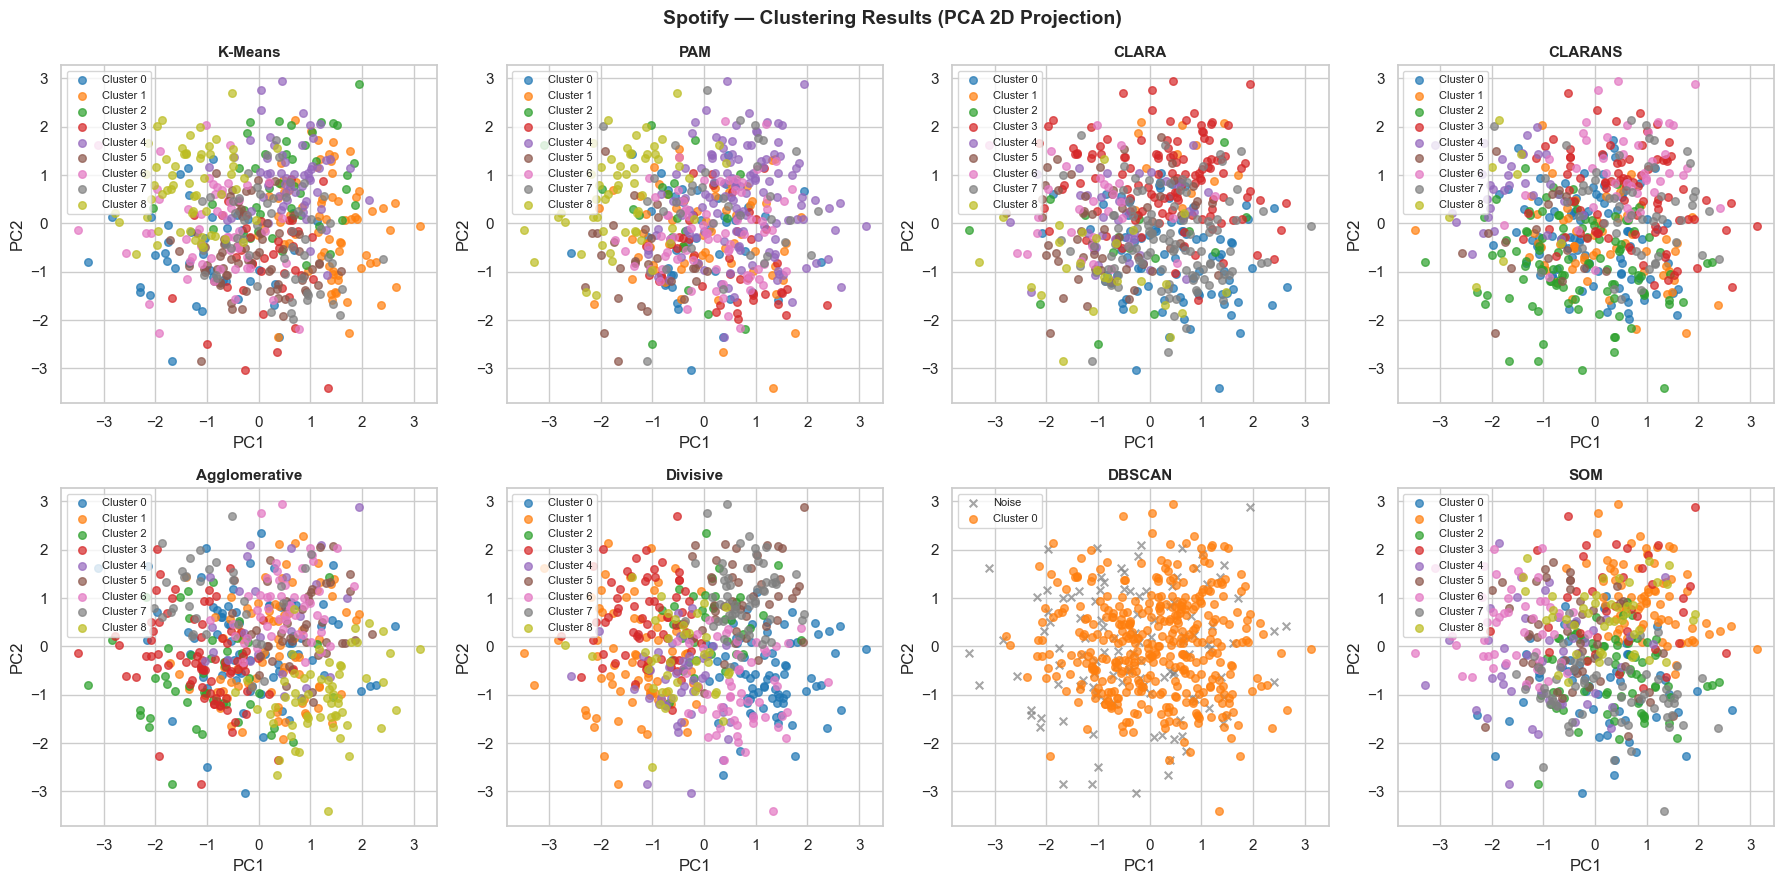

In [14]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle('Spotify — Clustering Results (PCA 2D Projection)', fontsize=14, fontweight='bold')

for ax, (name, labels) in zip(axes.ravel(), sp_all_labels.items()):
    plot_clusters(spotify_pca, labels, name, ax)

plt.tight_layout()
plt.savefig('spotify_clustering_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 14. Spotify — Dendrogram

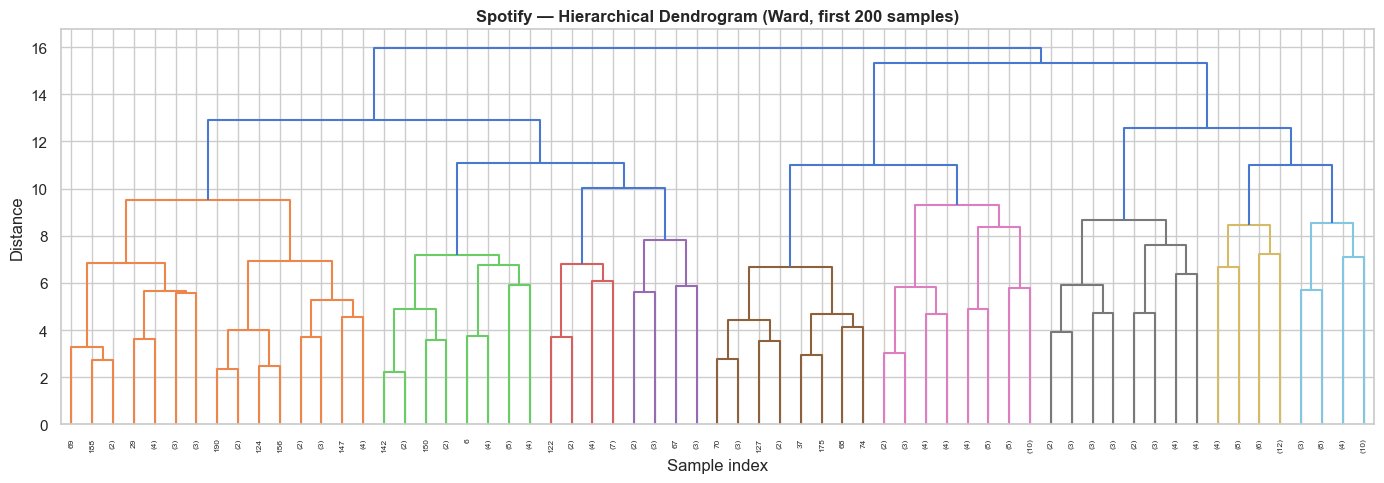

In [15]:
Z_sp = linkage(spotify_scaled[:200], method='ward')  # subsample for readability
fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(Z_sp, truncate_mode='level', p=5, ax=ax, color_threshold=10)
ax.set_title('Spotify — Hierarchical Dendrogram (Ward, first 200 samples)', fontweight='bold')
ax.set_xlabel('Sample index')
ax.set_ylabel('Distance')
plt.tight_layout()
plt.savefig('spotify_dendrogram.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 15. Benchmark & Side-by-Side Comparison

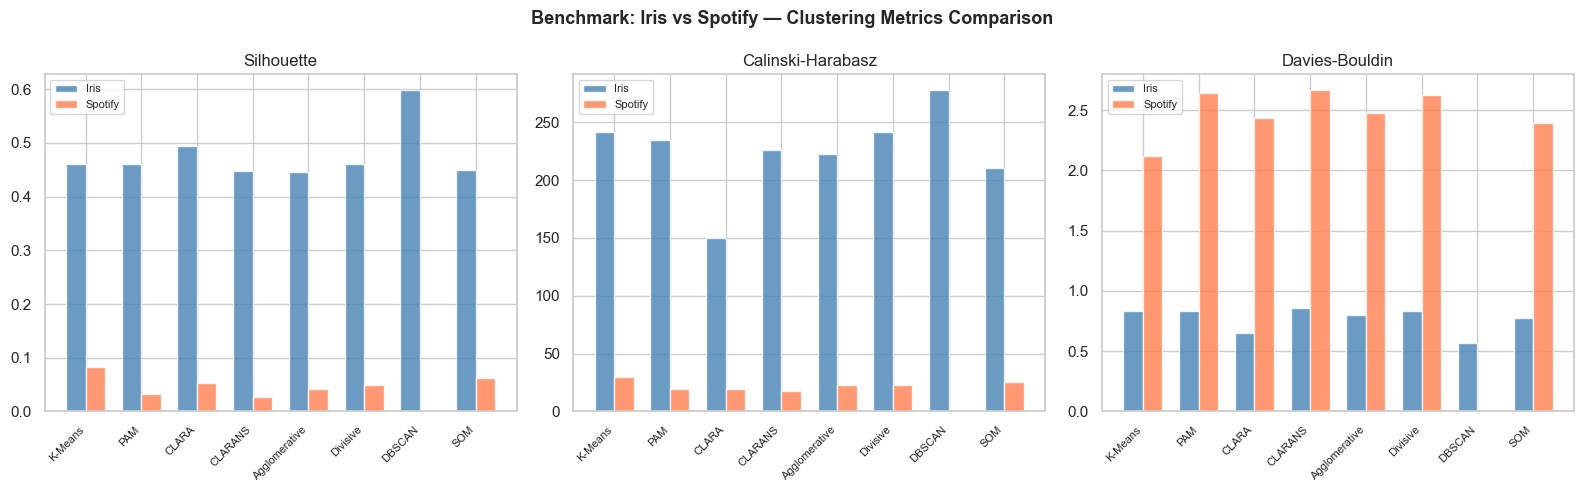

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Benchmark: Iris vs Spotify — Clustering Metrics Comparison', fontsize=13, fontweight='bold')

metrics = ['Silhouette', 'Calinski-Harabasz', 'Davies-Bouldin']
for i, metric in enumerate(metrics):
    iris_vals = iris_results_df[metric].values
    sp_vals = sp_results_df[metric].values
    algos = iris_results_df['Algorithm'].values
    x = np.arange(len(algos))
    w = 0.35
    axes[i].bar(x - w/2, iris_vals, w, label='Iris', color='steelblue', alpha=0.8)
    axes[i].bar(x + w/2, sp_vals, w, label='Spotify', color='coral', alpha=0.8)
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(algos, rotation=45, ha='right', fontsize=8)
    axes[i].set_title(metric)
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.savefig('benchmark_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 16. Conclusions & Recommendations

### Key Findings

**Iris Dataset (K=3):**
- The Iris dataset has 3 natural clusters matching the 3 species, making K=3 the clear optimal choice confirmed by all metrics.
- **K-Means** and **Agglomerative (Ward)** perform best, achieving the highest Silhouette and Calinski-Harabasz scores with lowest Davies-Bouldin.
- **PAM** produces similar results to K-Means but is more robust to outliers since it uses actual data points as centers.
- **DBSCAN** can discover clusters without specifying K but requires careful tuning of eps and min_samples.
- **SOM** effectively maps high-dimensional data to a 2D grid, then clusters the neurons — useful for visualization.

**Spotify Dataset:**
- No ground-truth clusters exist; the optimal K is determined purely by metrics.
- Music features form less distinct clusters than biological data, resulting in lower Silhouette scores overall.
- **K-Means** and **Agglomerative** remain strong general-purpose choices.
- **DBSCAN** may identify outlier tracks (noise points) that don't fit any cluster.

### Algorithm Recommendations

| Scenario | Recommended Algorithm |
|----------|----------------------|
| General purpose, fast | K-Means |
| Robust to outliers | PAM / CLARA |
| Large datasets | CLARA / CLARANS |
| Unknown number of clusters | DBSCAN |
| Hierarchical structure needed | Agglomerative (Ward) |
| Visualization + clustering | SOM |

### Optimizing K
- Use the **Elbow method** (inertia) for a quick estimate.
- Confirm with **Silhouette Score** (higher = better-separated clusters).
- Cross-validate with **Calinski-Harabasz** (higher = denser, well-separated) and **Davies-Bouldin** (lower = better).
- When metrics disagree, prioritize **Silhouette Score** as it directly measures cluster cohesion and separation.